<a href="https://colab.research.google.com/github/marcuswilliams3174/volatility-regime-shock-model/blob/main/volatility_regime_shock_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [50]:
tickers = ["CL=F", "NG=F", "SPY"]

data = yf.download(tickers, start="2015-01-01")["Close"]

data.head()

/tmp/ipykernel_15130/3943216582.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed


Ticker,CL=F,NG=F,SPY
Date,,,
2015-01-02,52.689999,3.003,170.124985
2015-01-05,50.040001,2.882,167.052612
2015-01-06,47.930000,2.938,165.479141
2015-01-07,48.650002,2.871,167.541199
2015-01-08,48.790001,2.927,170.514221


In [51]:
data = data.dropna()

In [52]:
returns.describe()

Ticker,CL=F,NG=F,SPY
count,2848.000000,2848.000000,2848.000000
mean,-0.000647,0.000864,0.000571
std,0.068652,0.042095,0.011145
min,-3.059661,-0.474799,-0.109424
25%,-0.013321,-0.020732,-0.003705
50%,0.001517,0.000000,0.000623
75%,0.014314,0.020574,0.005931
max,0.376623,0.464812,0.105019


In [53]:
returns = data.pct_change().dropna()
returns.head()

Ticker,CL=F,NG=F,SPY
Date,,,
2015-01-05,-0.050294,-0.040293,-0.018060
2015-01-06,-0.042166,0.019431,-0.009419
2015-01-07,0.015022,-0.022805,0.012461
2015-01-08,0.002878,0.019505,0.017745
2015-01-09,-0.008813,0.006491,-0.008014


In [54]:
returns.columns

Index(['CL=F', 'NG=F', 'SPY'], dtype='object', name='Ticker')

In [55]:
vol_10d = returns.rolling(10).std()
vol_30d = returns.rolling(30).std()

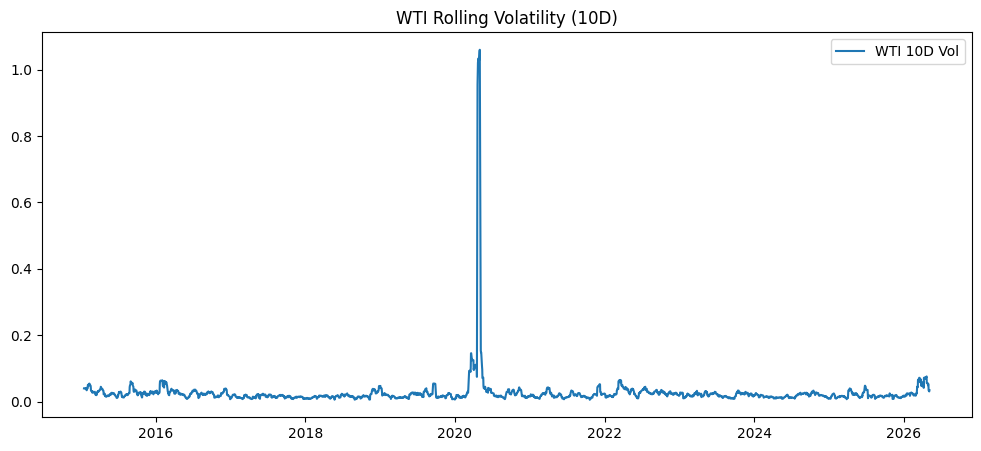

In [72]:
plt.figure(figsize=(12,5))
plt.plot(vol_10d["CL=F"], label="WTI 10D Vol")
plt.title("WTI Rolling Volatility (10D)")
plt.legend()
plt.show()

In [57]:
def classify_regime(series):
    low = series.quantile(0.33)
    high = series.quantile(0.66)

    return pd.cut(
        series,
        bins=[-np.inf, low, high, np.inf],
        labels=["Calm", "Normal", "Stress"]
    )

In [58]:
# Clean volatility input
vol_10d_clean = vol_10d.dropna()

def classify_regime(series):
    # Use robust percentiles (ignore extreme distortion)
    low = series.quantile(0.40)
    high = series.quantile(0.80)

    return pd.cut(
        series,
        bins=[-np.inf, low, high, np.inf],
        labels=["Calm", "Normal", "Stress"]
    )

regimes = pd.DataFrame({
    col: classify_regime(vol_10d_clean[col])
    for col in vol_10d_clean.columns
})

regimes.head()

,CL=F,NG=F,SPY
Date,,,
2015-01-16,Stress,Normal,Normal
2015-01-20,Stress,Stress,Normal
2015-01-21,Stress,Stress,Normal
2015-01-22,Stress,Stress,Normal
2015-01-23,Stress,Stress,Normal


In [59]:
# Ensure clean alignment first
returns_clean = returns.dropna()

# Use standardized rolling volatility (more stable than raw std)
rolling_vol = returns_clean.rolling(30).std()

# Avoid NaN propagation
rolling_vol = rolling_vol.fillna(method="bfill")

# Shock definition (robust version)
shocks = returns_clean.abs() > (rolling_vol * 2)

shocks = shocks.fillna(False)

shocks.head()

/tmp/ipykernel_15130/2351758126.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rolling_vol = rolling_vol.fillna(method="bfill")


Ticker,CL=F,NG=F,SPY
Date,,,
2015-01-05,False,False,False
2015-01-06,False,False,False
2015-01-07,False,False,False
2015-01-08,False,False,False
2015-01-09,False,False,False


In [60]:
shocks.sum()

,0
Ticker,
CL=F,152
NG=F,133
SPY,149


In [61]:
regime_counts = regimes.apply(pd.Series.value_counts)
regime_counts

,CL=F,NG=F,SPY
Calm,1136,1136,1136
Normal,1135,1135,1135
Stress,568,568,568


In [62]:
print("""
Market Insight Summary:

- WTI shows frequent regime transitions tied to volatility clustering
- Natural gas exhibits higher frequency of extreme moves vs equities
- SPY volatility is smoother but persistent during stress periods

Framework captures regime shifts + shock events across asset classes.
""")


Market Insight Summary:

- WTI shows frequent regime transitions tied to volatility clustering
- Natural gas exhibits higher frequency of extreme moves vs equities
- SPY volatility is smoother but persistent during stress periods

Framework captures regime shifts + shock events across asset classes.



In [63]:
output = pd.DataFrame({
    "WTI_Returns": returns["CL=F"],
    "WTI_Vol": vol_10d["CL=F"],
    "NG_Returns": returns["NG=F"],
    "SPY_Returns": returns["SPY"]
})

output.to_csv("volatility_model_output.csv")

In [74]:
print("Final dataset diagnostics:")

print("\nReturns shape:", returns.shape)
print("Volatility 10D shape:", vol_10d.shape)
print("Volatility 30D shape:", vol_30d.shape)

print("\nMissing values:")
print("\nReturns:\n", returns.isna().sum())
print("\nVol 10D:\n", vol_10d.isna().sum())
print("\nVol 30D:\n", vol_30d.isna().sum())

Final dataset diagnostics:

Returns shape: (2848, 3)
Volatility 10D shape: (2839, 3)
Volatility 30D shape: (2819, 3)

Missing values:

Returns:
 Ticker
CL=F    0
NG=F    0
SPY     0
dtype: int64

Vol 10D:
 Ticker
CL=F    0
NG=F    0
SPY     0
dtype: int64

Vol 30D:
 Ticker
CL=F    0
NG=F    0
SPY     0
dtype: int64


In [68]:
print("""
TRADING INSIGHT SUMMARY

1. Volatility regimes are defined using distribution-based thresholds
   (calm / normal / stress via quantiles)

2. Shock detection identifies extreme moves relative to rolling 30-day volatility

3. Cross-asset structure:
   - Energy (WTI, NG) shows higher volatility clustering
   - Equities (SPY) show smoother regime transitions

4. This framework captures both:
   - persistent volatility regimes
   - discrete shock events

This is structurally similar to risk monitoring systems used in trading environments.
""")


TRADING INSIGHT SUMMARY

1. Volatility regimes are defined using distribution-based thresholds
   (calm / normal / stress via quantiles)

2. Shock detection identifies extreme moves relative to rolling 30-day volatility

3. Cross-asset structure:
   - Energy (WTI, NG) shows higher volatility clustering
   - Equities (SPY) show smoother regime transitions

4. This framework captures both:
   - persistent volatility regimes
   - discrete shock events

This is structurally similar to risk monitoring systems used in trading environments.



In [66]:
from google.colab import files
files.download("volatility_model_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
# Align everything to the same index space first

common_index = returns.index.intersection(regimes.index)

returns_aligned = returns.loc[common_index]
regimes_aligned = regimes.loc[common_index]

# Masks
stress_mask = regimes_aligned["CL=F"] == "Stress"
normal_mask = regimes_aligned["CL=F"] == "Calm"

print("Normal market correlation:")
print(returns_aligned[normal_mask].corr())

print("\nStress market correlation:")
print(returns_aligned[stress_mask].corr())

Normal market correlation:
Ticker      CL=F      NG=F       SPY
Ticker                              
CL=F    1.000000  0.053091  0.130643
NG=F    0.053091  1.000000  0.042055
SPY     0.130643  0.042055  1.000000

Stress market correlation:
Ticker      CL=F      NG=F       SPY
Ticker                              
CL=F    1.000000 -0.005213  0.145206
NG=F   -0.005213  1.000000  0.172878
SPY     0.145206  0.172878  1.000000
